In [ ]:
!pip install yfinance

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


  Using cached yfinance-0.2.66-py2.py3-none-any.whl.metadata (6.0 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached peewee-3.18.2.tar.gz (949 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata (13 kB)
Using cached yfinance-0.2.66-py2.py3-none-any.whl (123 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl (1.6 MB)
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15618 sha256=77b2fde51a08639ada6e0fcda4e56e289e42d58a9037bb13b90cd34fa7c1319c
  Stored in directory: c:\users\mathiane kara

In [ ]:
import yfinance as jy
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import numpy as np

### Extract Yahoo finance data

In [34]:
# Define the currency pair
pair = "USDZAR=X"  # USD to South African Rand

# Download historical data (last 24 month, daily)
data = yf.download(pair, period="120mo", interval="1d")

# Convert to Pandas DataFrame
forex_df = pd.DataFrame(data)

# Inspect the first few row
forex_df


C:\Users\Mathiane karabo\AppData\Local\Temp\ipykernel_13608\3560607890.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(pair, period="120mo", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,USDZAR=X,USDZAR=X,USDZAR=X,USDZAR=X,USDZAR=X
Date,,,,,
2015-09-28,13.861880,14.062030,13.799900,13.861880,0
2015-09-29,14.057400,14.153300,13.887780,14.056620,0
2015-09-30,13.968380,13.968280,13.790500,13.968280,0
2015-10-01,13.825780,13.869980,13.719000,13.824970,0
2015-10-02,13.919280,14.016290,13.750480,13.918880,0
...,...,...,...,...,...
2025-09-23,17.330900,17.381300,17.228701,17.330900,0
2025-09-24,17.228100,17.344999,17.207001,17.228100,0


In [23]:
forex_df = forex_df[['Close']]
forex_df.index

DatetimeIndex(['2015-09-28', '2015-09-29', '2015-09-30', '2015-10-01',
               '2015-10-02', '2015-10-05', '2015-10-06', '2015-10-07',
               '2015-10-08', '2015-10-09',
               ...
               '2025-09-16', '2025-09-17', '2025-09-18', '2025-09-19',
               '2025-09-22', '2025-09-23', '2025-09-24', '2025-09-25',
               '2025-09-26', '2025-09-27'],
              dtype='datetime64[ns]', name='Date', length=2605, freq=None)

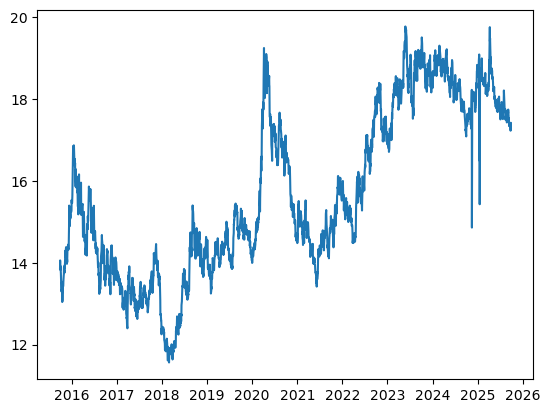

In [25]:
plt.plot(forex_df.index, forex_df['Close'])

### Convert to supervised learning problem

In [ ]:
def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
  first_date = pd.to_datetime(first_date_str)
  last_date  = pd.to_datetime(last_date_str)

  target_date = first_date
  
  dates = []
  X, Y = [], []

  last_time = False
  while True:
    df_subset = dataframe.loc[:target_date].tail(n+1)
    
    if len(df_subset) != n+1:
      print(f'Error: Window of size {n} is too large for date {target_date}')
      return

    values = df_subset['Close'].to_numpy()
    x, y = values[:-1], values[-1]

    dates.append(target_date)
    X.append(x)
    Y.append(y)

    next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)]
    next_datetime_str = str(next_week.head(2).tail(1).index.values[0])
    next_date_str = next_datetime_str.split('T')[0]
    year_month_day = next_date_str.split('-')
    year, month, day = year_month_day
    next_date = datetime.datetime(day=int(day), month=int(month), year=int(year))
    
    if last_time:
      break
    
    target_date = next_date

    if target_date == last_date:
      last_time = True
    
  ret_df = pd.DataFrame({})
  ret_df['Target Date'] = dates
  
  X = np.array(X)
  for i in range(0, n):
    X[:, i]
    ret_df[f'Target-{n-i}'] = X[:, i]
  
  ret_df['Target'] = Y

  return ret_df

# Start day second time around: '2021-03-25'
windowed_df = df_to_windowed_df(forex_df, '2021-03-25', '2022-03-23', n=3)
windowed_df

AttributeError: type object 'datetime.datetime' has no attribute 'datetime'